# Credit Risk: Loan Default Prediction

Feedforward neural network comparison on a simulated 10,000-borrower loan dataset. See the repository README for the business case study.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("simulated_loan_default_10000.csv")

In [ ]:
print("FIRST 5 ROWS THE DATASET")
df.head()

FIRST 5 ROWS THE DATASET


,borrower_id,issue_d,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,total_acc,pub_rec,revol_util,fico_score,num_tl_90g_dpd_24m,application_type,addr_state,default
0,B100000,2021-07,16500,36 months,6.83,A,A5,10+ years,OWN,44755.54,Verified,car,2.10,0,1,9,24,0,53.22,712,1,Individual,WA,0
1,B100001,2016-07,9500,36 months,8.86,B,B2,9 years,RENT,54946.64,Source Verified,other,40.06,1,2,13,27,1,39.48,684,0,Individual,NC,0
2,B100002,2017-10,34500,36 months,6.85,A,A3,9 years,MORTGAGE,46797.40,Source Verified,debt_consolidation,17.18,1,0,10,25,0,53.33,719,1,Individual,AZ,0
3,B100003,2017-10,18000,36 months,5.00,A,A4,2 years,OWN,69069.77,Verified,car,8.39,0,0,9,22,1,30.53,759,0,Individual,PA,0
4,B100004,2016-01,12000,36 months,9.80,B,B4,3 years,MORTGAGE,125566.50,Verified,wedding,30.65,0,0,11,25,0,69.01,679,0,Individual,MD,0


In [ ]:
print("DATASET SHAPE")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


DATASET SHAPE
Number of rows    : 10000
Number of columns : 24


In [ ]:
print("COLUMN NAMES")
print(df.columns.tolist())

COLUMN NAMES
['borrower_id', 'issue_d', 'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'fico_score', 'num_tl_90g_dpd_24m', 'application_type', 'addr_state', 'default']


In [ ]:
print("DATA TYPES")
print(df.dtypes)


DATA TYPES
borrower_id             object
issue_d                 object
loan_amnt                int64
term                    object
int_rate               float64
grade                   object
sub_grade               object
emp_length              object
home_ownership          object
annual_inc             float64
verification_status     object
purpose                 object
dti                    float64
delinq_2yrs              int64
inq_last_6mths           int64
open_acc                 int64
total_acc                int64
pub_rec                  int64
revol_util             float64
fico_score               int64
num_tl_90g_dpd_24m       int64
application_type        object
addr_state              object
default                  int64
dtype: object


In [ ]:
#Checking for missing values
print("MISSING VALUES PER COLUMN")
print(df.isnull().sum())


MISSING VALUES PER COLUMN
borrower_id            0
issue_d                0
loan_amnt              0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
inq_last_6mths         0
open_acc               0
total_acc              0
pub_rec                0
revol_util             0
fico_score             0
num_tl_90g_dpd_24m     0
application_type       0
addr_state             0
default                0
dtype: int64


In [ ]:
 # Checking class distribution of the target variable
print("TARGET CLASS DISTRIBUTION: 'default'")
print(df["default"].value_counts())

TARGET CLASS DISTRIBUTION: 'default'
default
0    7940
1    2060
Name: count, dtype: int64


In [ ]:
print("TARGET CLASS PROPORTION")
print(df["default"].value_counts(normalize=True))


TARGET CLASS PROPORTION
default
0    0.794
1    0.206
Name: proportion, dtype: float64


In [ ]:
# Converting issue_d into issue_year and issue_month
# issue_d is useful as a time-related variable, but not in raw text form.
# so i want to convert it into numeric features the neural network can later use.

df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")

# Create new numeric columns
df["issue_year"] = df["issue_d"].dt.year
df["issue_month"] = df["issue_d"].dt.month


print("CHECK issue_d AFTER CONVERSION")

print(df[["issue_d", "issue_year", "issue_month"]].head())

CHECK issue_d AFTER CONVERSION
     issue_d  issue_year  issue_month
0 2021-07-01        2021            7
1 2016-07-01        2016            7
2 2017-10-01        2017           10
3 2017-10-01        2017           10
4 2016-01-01        2016            1


In [ ]:
# Droping columns that do not add predictive value directly
# borrower_id is only an identifier, so it should not be used as a predictor.
# issue_d is dropped after extracting issue_year and issue_month.

columns_to_drop = ["borrower_id", "issue_d"]

df = df.drop(columns=columns_to_drop)

print("COLUMNS AFTER DROPPING borrower_id AND issue_d")
print(df.columns.tolist())


COLUMNS AFTER DROPPING borrower_id AND issue_d
['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'fico_score', 'num_tl_90g_dpd_24m', 'application_type', 'addr_state', 'default', 'issue_year', 'issue_month']


In [ ]:
# Checking whether any missing values were introduced
# This is important because converting issue_d may create missing values
# if any date could not be parsed correctly.
print("MISSING VALUES AFTER issue_d TRANSFORMATION")
print(df.isnull().sum())

MISSING VALUES AFTER issue_d TRANSFORMATION
loan_amnt              0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
inq_last_6mths         0
open_acc               0
total_acc              0
pub_rec                0
revol_util             0
fico_score             0
num_tl_90g_dpd_24m     0
application_type       0
addr_state             0
default                0
issue_year             0
issue_month            0
dtype: int64


In [ ]:
# Separate predictors (X) and target (y)
# My target is 'default'
# All other remaining columns are predictors

X = df.drop(columns=["default"])
y = df["default"]

print("PREDICTOR MATRIX SHAPE")
print(X.shape)

print("TARGET VECTOR SHAPE")
print(y.shape)


PREDICTOR MATRIX SHAPE
(10000, 23)
TARGET VECTOR SHAPE
(10000,)


In [ ]:
# Identify numeric and categorical columns
# This will help us in the next step when we do preprocessing
# such as encoding categorical variables and scaling numeric ones.

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


print("NUMERIC COLUMNS")
print(numeric_cols)


print("CATEGORICAL COLUMNS")
print(categorical_cols)

NUMERIC COLUMNS
['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'fico_score', 'num_tl_90g_dpd_24m']
CATEGORICAL COLUMNS
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type', 'addr_state']


In [ ]:
# 11. Quick review of cardinality for categorical variables
# This helps understand how many unique categories each
# categorical variable has before encoding.

print("NUMBER OF UNIQUE VALUES IN EACH CATEGORICAL COLUMN")
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")


# 12. Optional: inspect summary statistics for numeric columns

print("SUMMARY STATISTICS FOR NUMERIC VARIABLES")
print(X[numeric_cols].describe())


# 13. Confirm that num_tl_90g_dpd_24m is included

print("CHECK THAT 'num_tl_90g_dpd_24m' IS INCLUDED")

print("num_tl_90g_dpd_24m" in X.columns)


NUMBER OF UNIQUE VALUES IN EACH CATEGORICAL COLUMN
term: 2 unique values
grade: 6 unique values
sub_grade: 27 unique values
emp_length: 11 unique values
home_ownership: 4 unique values
verification_status: 3 unique values
purpose: 11 unique values
application_type: 2 unique values
addr_state: 20 unique values
SUMMARY STATISTICS FOR NUMERIC VARIABLES
          loan_amnt      int_rate     annual_inc           dti   delinq_2yrs  inq_last_6mths     open_acc     total_acc       pub_rec    revol_util  fico_score  num_tl_90g_dpd_24m
count  10000.000000  10000.000000   10000.000000  10000.000000  10000.000000    10000.000000  10000.00000  10000.000000  10000.000000  10000.000000  10000.0000        10000.000000
mean   20575.600000      9.673078   76141.435097     14.555420      0.363100        0.896000     11.96470     23.953900      0.155500     50.704336    689.9128            0.216800
std    11361.170374      2.898790   44704.486644      8.895948      0.607697        0.941421      3.33091   

In [ ]:
# DATA SPLITTING, ENCODING, SCALING, AND CLASS WEIGHTS
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
# Drop 'grade' because 'sub_grade' is a more detailed
# version of the same credit-risk information

if "grade" in X.columns:
    X = X.drop(columns=["grade"])

print("COLUMNS AFTER DROPPING 'grade'")
print(X.columns.tolist())

COLUMNS AFTER DROPPING 'grade'
['loan_amnt', 'term', 'int_rate', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'fico_score', 'num_tl_90g_dpd_24m', 'application_type', 'addr_state', 'issue_year', 'issue_month']


In [ ]:
# Re-identify numeric and categorical columns
# We use np.number so that columns like int32/int64/float64
# are all captured correctly. This is important because
# issue_year and issue_month may not always appear as int64.

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("UPDATED NUMERIC COLUMNS")
print(numeric_cols)

print("UPDATED CATEGORICAL COLUMNS")
print(categorical_cols)

UPDATED NUMERIC COLUMNS
['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_util', 'fico_score', 'num_tl_90g_dpd_24m', 'issue_year', 'issue_month']
UPDATED CATEGORICAL COLUMNS
['term', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type', 'addr_state']


In [ ]:
# 5. First split: separate training set (70%) from temp set (30%)
# We use stratify=y so that the class distribution of default/non-default
# is preserved across the splits.
# split temp set into validation (15%) and test (15%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)



X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


In [ ]:
# 7. Print split shapes to confirm the 70/15/15 split

print("DATA SPLIT SHAPES")

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape   : {y_val.shape}")
print(f"y_test shape  : {y_test.shape}")

DATA SPLIT SHAPES
X_train shape : (7000, 22)
X_val shape   : (1500, 22)
X_test shape  : (1500, 22)
y_train shape : (7000,)
y_val shape   : (1500,)
y_test shape  : (1500,)


In [ ]:
# Checking class proportions after splitting
# This confirms that stratification worked correctly.


print("CLASS DISTRIBUTION IN TRAINING SET")
print(y_train.value_counts(normalize=True))

print("CLASS DISTRIBUTION IN VALIDATION SET")
print(y_val.value_counts(normalize=True))


print("CLASS DISTRIBUTION IN TEST SET")
print(y_test.value_counts(normalize=True))

CLASS DISTRIBUTION IN TRAINING SET
default
0    0.794
1    0.206
Name: proportion, dtype: float64
CLASS DISTRIBUTION IN VALIDATION SET
default
0    0.794
1    0.206
Name: proportion, dtype: float64
CLASS DISTRIBUTION IN TEST SET
default
0    0.794
1    0.206
Name: proportion, dtype: float64


In [ ]:
# Building preprocessing pipeline
# For numeric columns:
#   - apply StandardScaler so all numeric features are on a similar scale
#     (very important for neural networks)
#
# For categorical columns:
#   - apply OneHotEncoder to convert categories into binary indicator columns
#   - handle_unknown='ignore' ensures that if a category appears in validation/test
#     but not in training, the code will not crash

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

In [ ]:
# Fit the preprocessor on the training data only
# This is very important to avoid data leakage.
# We learn scaling/encoding rules only from the training set.

X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same learned transformations to validation and test sets
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


# Print the processed shapes

print("PROCESSED DATA SHAPES")
print(f"X_train_processed shape : {X_train_processed.shape}")
print(f"X_val_processed shape   : {X_val_processed.shape}")
print(f"X_test_processed shape  : {X_test_processed.shape}")

PROCESSED DATA SHAPES
X_train_processed shape : (7000, 94)
X_val_processed shape   : (1500, 94)
X_test_processed shape  : (1500, 94)


In [ ]:
# Get the final feature names after preprocessing
# This is useful for documentation and checking that
# one-hot encoding worked as expected.

encoded_feature_names = preprocessor.get_feature_names_out()

print("NUMBER OF FINAL FEATURES AFTER PREPROCESSING")
print(len(encoded_feature_names))

print("FIRST 30 FINAL FEATURE NAMES")
print(encoded_feature_names[:30])


# Convert processed arrays to float32
# TensorFlow/Keras works efficiently with float32 data.

X_train_processed = X_train_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

# Convert target arrays as well
y_train_array = y_train.to_numpy().astype(np.float32)
y_val_array = y_val.to_numpy().astype(np.float32)
y_test_array = y_test.to_numpy().astype(np.float32)

NUMBER OF FINAL FEATURES AFTER PREPROCESSING
94
FIRST 30 FINAL FEATURE NAMES
['num__loan_amnt' 'num__int_rate' 'num__annual_inc' 'num__dti'
 'num__delinq_2yrs' 'num__inq_last_6mths' 'num__open_acc' 'num__total_acc'
 'num__pub_rec' 'num__revol_util' 'num__fico_score'
 'num__num_tl_90g_dpd_24m' 'num__issue_year' 'num__issue_month'
 'cat__term_36 months' 'cat__term_60 months' 'cat__sub_grade_A1'
 'cat__sub_grade_A2' 'cat__sub_grade_A3' 'cat__sub_grade_A4'
 'cat__sub_grade_A5' 'cat__sub_grade_B1' 'cat__sub_grade_B2'
 'cat__sub_grade_B3' 'cat__sub_grade_B4' 'cat__sub_grade_B5'
 'cat__sub_grade_C1' 'cat__sub_grade_C2' 'cat__sub_grade_C3'
 'cat__sub_grade_C4']


In [ ]:
# Compute class weights using the training set only
# This tells the model to pay more attention to the minority class (default = 1)

classes = np.unique(y_train_array)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_array
)

class_weight_dict = {
    int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)
}

print("CLASS WEIGHTS")
print(class_weight_dict)


CLASS WEIGHTS
{0: 0.6297229219143576, 1: 2.4271844660194173}


In [ ]:
# Store input dimension for neural network construction later
# This gives the number of input features the neural network will receive.

input_dim = X_train_processed.shape[1]
print("INPUT DIMENSION FOR THE NEURAL NETWORK")
print(input_dim)

INPUT DIMENSION FOR THE NEURAL NETWORK
94


In [ ]:
# Final confirmation that num_tl_90g_dpd_24m survived preprocessing
# This checks whether the original predictor is part of the numeric transformer list.


print("CHECK THAT 'num_tl_90g_dpd_24m' IS STILL INCLUDED")
print("num_tl_90g_dpd_24m" in numeric_cols)

CHECK THAT 'num_tl_90g_dpd_24m' IS STILL INCLUDED
True


In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# Set random seeds for reproducibility
# This helps ensure that results are more reproducible when I rerun the notebook.

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Build Configuration 1 model
# This is the baseline feedforward neural network.
# It is intentionally simple in optimisation and regularisation.
config1_model = Sequential([
    layers.Input(shape=(input_dim,)),

    # First hidden layer
    layers.Dense(64, activation='relu'),

    # Second hidden layer
    layers.Dense(32, activation='relu'),

    # Third hidden layer
    layers.Dense(16, activation='relu'),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

In [ ]:

#  Using Optimizer: SGD (simple baseline optimiser)
#  Loss: binary_crossentropy which is appropriate for binary classification
#  Metrics: accuracy, precision, recall, and AUC

config1_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
# Display model summary
print("CONFIGURATION 1 MODEL SUMMARY")
config1_model.summary()

CONFIGURATION 1 MODEL SUMMARY


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 64)             │         6,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
# applying class_weight to help the model pay more attention
# to the minority class (default = 1)

history_config1 = config1_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5047 - auc: 0.5953 - loss: 0.6814 - precision: 0.2419 - recall: 0.6581 - val_accuracy: 0.5707 - val_auc: 0.6272 - val_loss: 0.6818 - val_precision: 0.2690 - val_recall: 0.6311
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6083 - auc: 0.6964 - loss: 0.6470 - precision: 0.3056 - recall: 0.7087 - val_accuracy: 0.6213 - val_auc: 0.6816 - val_loss: 0.6516 - val_precision: 0.3005 - val_recall: 0.6311
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6599 - auc: 0.7343 - loss: 0.6145 - precision: 0.3410 - recall: 0.6983 - val_accuracy: 0.6560 - val_auc: 0.7024 - val_loss: 0.6218 - val_precision: 0.3225 - val_recall: 0.6084
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6860 - auc: 0.7514 - loss: 0.5949 - precision: 0.3625 - recall: 0.6914 - val_accuracy: 0.6760 - val_auc: 0.7100 - val_loss: 0.6064 - val_precision: 0.3400 - val_recall: 0.6084
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:
# Evaluate the model on the validation set
# This gives the validation loss and metrics directly from Keras.
print("CONFIGURATION 1 - VALIDATION EVALUATION FROM KERAS")
val_results_config1 = config1_model.evaluate(
    X_val_processed,
    y_val_array,
    verbose=0
)
for name, value in zip(config1_model.metrics_names, val_results_config1):
    print(f"{name}: {value:.4f}")

CONFIGURATION 1 - VALIDATION EVALUATION FROM KERAS
loss: 0.5825
compile_metrics: 0.6820


In [ ]:
# Generate validation predicted probabilities
# These probabilities are needed for:
# AUC calculation, converting probabilities into class predictions
# later comparison with other configurations

y_val_pred_prob_config1 = config1_model.predict(X_val_processed).ravel()
y_val_pred_class_config1 = (y_val_pred_prob_config1 >= 0.5).astype(int)


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Compute validation metrics using sklearn
# These are easier to store and compare later across configurations.

config1_accuracy = accuracy_score(y_val_array, y_val_pred_class_config1)
config1_precision = precision_score(y_val_array, y_val_pred_class_config1, zero_division=0)
config1_recall = recall_score(y_val_array, y_val_pred_class_config1, zero_division=0)
config1_f1 = f1_score(y_val_array, y_val_pred_class_config1, zero_division=0)
config1_auc = roc_auc_score(y_val_array, y_val_pred_prob_config1)


print("CONFIGURATION 1 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config1_accuracy:.4f}")
print(f"Precision: {config1_precision:.4f}")
print(f"Recall   : {config1_recall:.4f}")
print(f"F1-score : {config1_f1:.4f}")
print(f"AUC      : {config1_auc:.4f}")

# Print confusion matrix
print("CONFIGURATION 1 - CONFUSION MATRIX (VALIDATION SET)")
cm_config1 = confusion_matrix(y_val_array, y_val_pred_class_config1)
print(cm_config1)

CONFIGURATION 1 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.6820
Precision: 0.3427
Recall   : 0.5922
F1-score : 0.4342
AUC      : 0.7194
CONFIGURATION 1 - CONFUSION MATRIX (VALIDATION SET)
[[840 351]
 [126 183]]


In [ ]:
# Print classification report
# This includes macro average and weighted average metrics,

print("CONFIGURATION 1 - CLASSIFICATION REPORT (VALIDATION SET)")
print(classification_report(y_val_array, y_val_pred_class_config1, digits=4, zero_division=0))


CONFIGURATION 1 - CLASSIFICATION REPORT (VALIDATION SET)
              precision    recall  f1-score   support

         0.0     0.8696    0.7053    0.7789      1191
         1.0     0.3427    0.5922    0.4342       309

    accuracy                         0.6820      1500
   macro avg     0.6061    0.6488    0.6065      1500
weighted avg     0.7610    0.6820    0.7079      1500



RESULTS TABLE AFTER CONFIGURATION 1
                                      Configuration  Accuracy  Precision    Recall  F1_Score      AUC
0  Config 1 - Baseline DNN (SGD, no regularisation)     0.682   0.342697  0.592233  0.434164  0.71937


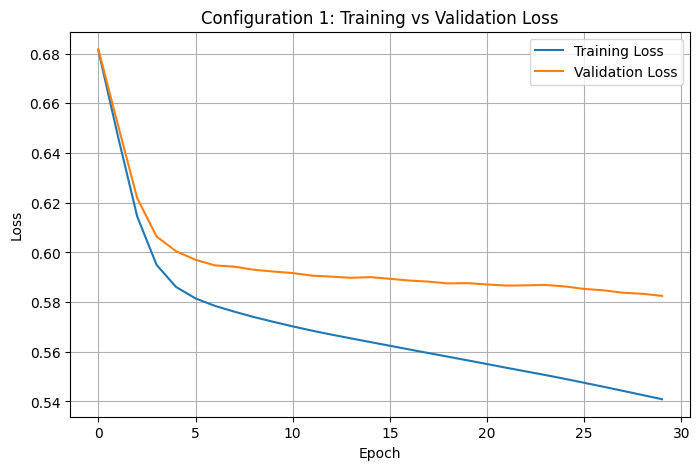

In [ ]:
# Store results in a comparison table
results_df = pd.DataFrame([
    {
        "Configuration": "Config 1 - Baseline DNN (SGD, no regularisation)",
        "Accuracy": config1_accuracy,
        "Precision": config1_precision,
        "Recall": config1_recall,
        "F1_Score": config1_f1,
        "AUC": config1_auc
    }
])

print("RESULTS TABLE AFTER CONFIGURATION 1")
print(results_df)

# Plot training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_config1.history['loss'], label='Training Loss')
plt.plot(history_config1.history['val_loss'], label='Validation Loss')
plt.title('Configuration 1: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

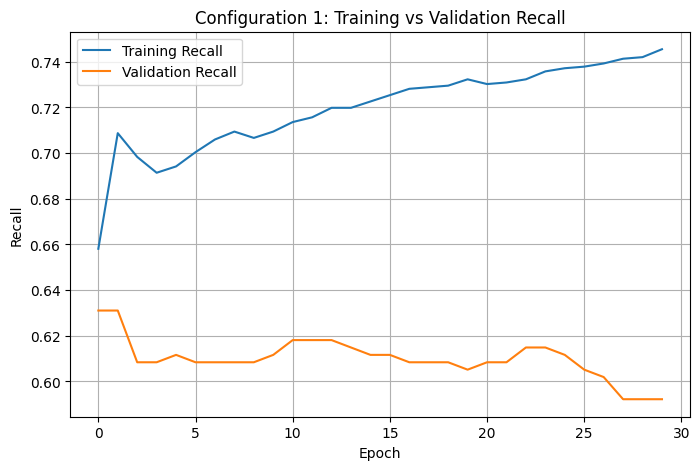

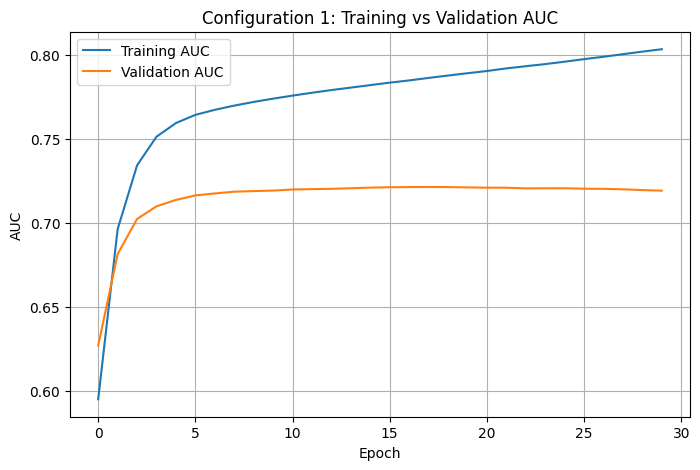

In [ ]:
# Plot additional learning curves for recall and AUC
# These are useful because the dataset is imbalanced,
# so recall and AUC matter more than accuracy alone.

plt.figure(figsize=(8, 5))
plt.plot(history_config1.history['recall'], label='Training Recall')
plt.plot(history_config1.history['val_recall'], label='Validation Recall')
plt.title('Configuration 1: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_config1.history['auc'], label='Training AUC')
plt.plot(history_config1.history['val_auc'], label='Validation AUC')
plt.title('Configuration 1: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Print last-epoch training history values
# This helps inspect where the model ended training.
print("LAST EPOCH METRICS FOR CONFIGURATION 1")

for key, value in history_config1.history.items():
    print(f"{key}: {value[-1]:.4f}")

LAST EPOCH METRICS FOR CONFIGURATION 1
accuracy: 0.7207
auc: 0.8034
loss: 0.5409
precision: 0.4037
recall: 0.7455
val_accuracy: 0.6820
val_auc: 0.7193
val_loss: 0.5825
val_precision: 0.3427
val_recall: 0.5922


In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
# Build Configuration 2 model
config2_model = Sequential([
    layers.Input(shape=(input_dim,)),

    # First hidden layer
    layers.Dense(64, activation='relu'),

    # Second hidden layer
    layers.Dense(32, activation='relu'),

    # Third hidden layer
    layers.Dense(16, activation='relu'),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])


In [ ]:
# Compile the model
# Difference from Config 1:
# using SGD with momentum.
# Momentum helps accelerate learning and stabilise updates.

config2_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


In [ ]:
# Display model summary
print("CONFIGURATION 2 MODEL SUMMARY")
config2_model.summary()


CONFIGURATION 2 MODEL SUMMARY


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │         6,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history_config2 = config2_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6624 - auc: 0.7205 - loss: 0.6167 - precision: 0.3386 - recall: 0.6699 - val_accuracy: 0.6660 - val_auc: 0.7202 - val_loss: 0.5940 - val_precision: 0.3328 - val_recall: 0.6181
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6929 - auc: 0.7671 - loss: 0.5776 - precision: 0.3727 - recall: 0.7184 - val_accuracy: 0.6720 - val_auc: 0.7219 - val_loss: 0.5881 - val_precision: 0.3381 - val_recall: 0.6181
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6991 - auc: 0.7767 - loss: 0.5682 - precision: 0.3799 - recall: 0.7282 - val_accuracy: 0.6720 - val_auc: 0.7204 - val_loss: 0.5900 - val_precision: 0.3375 - val_recall: 0.6149
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7074 - auc: 0.7841 - loss: 0.5606 - precision: 0.3899 - recall: 0.7441 - val_accuracy: 0.6767 - val_auc: 0.7188 - val_loss: 0.5898 - val_precision: 0.3412 - val_recall: 0.6117
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:
# Generate validation predicted probabilities
y_val_pred_prob_config2 = config2_model.predict(X_val_processed).ravel()

# Convert probabilities to predicted classes
y_val_pred_class_config2 = (y_val_pred_prob_config2 >= 0.5).astype(int)

# Compute validation metrics using sklearn
config2_accuracy = accuracy_score(y_val_array, y_val_pred_class_config2)
config2_precision = precision_score(y_val_array, y_val_pred_class_config2, zero_division=0)
config2_recall = recall_score(y_val_array, y_val_pred_class_config2, zero_division=0)
config2_f1 = f1_score(y_val_array, y_val_pred_class_config2, zero_division=0)
config2_auc = roc_auc_score(y_val_array, y_val_pred_prob_config2)

print("CONFIGURATION 2 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config2_accuracy:.4f}")
print(f"Precision: {config2_precision:.4f}")
print(f"Recall   : {config2_recall:.4f}")
print(f"F1-score : {config2_f1:.4f}")
print(f"AUC      : {config2_auc:.4f}")


# Confusion matrix
print("CONFIGURATION 2 - CONFUSION MATRIX (VALIDATION SET)")
cm_config2 = confusion_matrix(y_val_array, y_val_pred_class_config2)
print(cm_config2)


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CONFIGURATION 2 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.6867
Precision: 0.3215
Recall   : 0.4693
F1-score : 0.3816
AUC      : 0.6491
CONFIGURATION 2 - CONFUSION MATRIX (VALIDATION SET)
[[885 306]
 [164 145]]


In [ ]:
# Classification report
print("CONFIGURATION 2 - CLASSIFICATION REPORT (VALIDATION SET)")
print(classification_report(y_val_array, y_val_pred_class_config2, digits=4, zero_division=0))

CONFIGURATION 2 - CLASSIFICATION REPORT (VALIDATION SET)
              precision    recall  f1-score   support

         0.0     0.8437    0.7431    0.7902      1191
         1.0     0.3215    0.4693    0.3816       309

    accuracy                         0.6867      1500
   macro avg     0.5826    0.6062    0.5859      1500
weighted avg     0.7361    0.6867    0.7060      1500



RESULTS TABLE AFTER CONFIGURATION 2
                                      Configuration  Accuracy  Precision    Recall  F1_Score       AUC
0  Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1              Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056


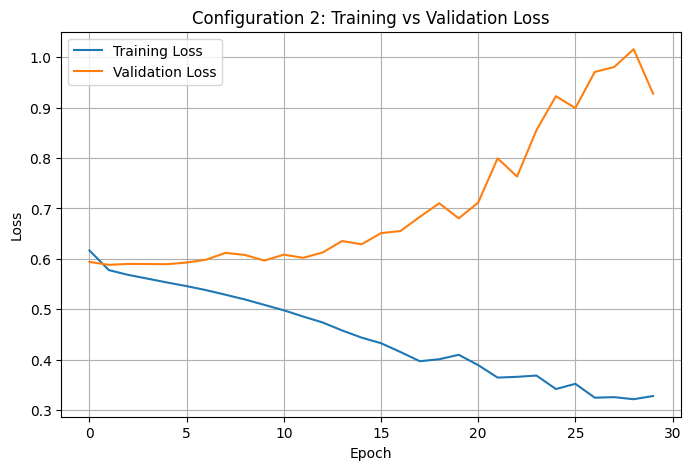

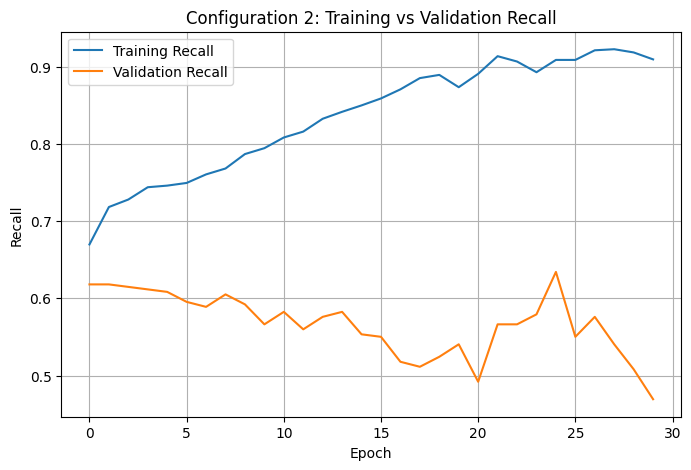

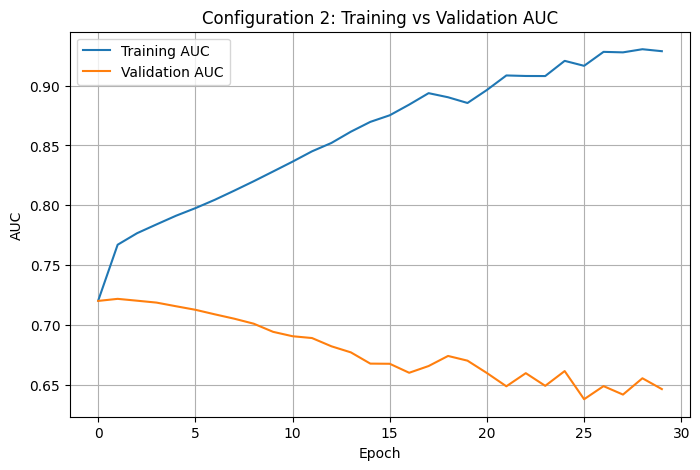

LAST EPOCH METRICS FOR CONFIGURATION 2
accuracy: 0.8327
auc: 0.9287
loss: 0.3277
precision: 0.5576
recall: 0.9098
val_accuracy: 0.6867
val_auc: 0.6466
val_loss: 0.9279
val_precision: 0.3215
val_recall: 0.4693


In [ ]:
# Add results to the comparison table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Configuration": "Config 2 - Same DNN (SGD + momentum)",
        "Accuracy": config2_accuracy,
        "Precision": config2_precision,
        "Recall": config2_recall,
        "F1_Score": config2_f1,
        "AUC": config2_auc
    }])
], ignore_index=True)

print("RESULTS TABLE AFTER CONFIGURATION 2")
print(results_df)


# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_config2.history['loss'], label='Training Loss')
plt.plot(history_config2.history['val_loss'], label='Validation Loss')
plt.title('Configuration 2: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation recall
plt.figure(figsize=(8, 5))
plt.plot(history_config2.history['recall'], label='Training Recall')
plt.plot(history_config2.history['val_recall'], label='Validation Recall')
plt.title('Configuration 2: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation AUC
plt.figure(figsize=(8, 5))
plt.plot(history_config2.history['auc'], label='Training AUC')
plt.plot(history_config2.history['val_auc'], label='Validation AUC')
plt.title('Configuration 2: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


# Print last-epoch training history values
print("LAST EPOCH METRICS FOR CONFIGURATION 2")
for key, value in history_config2.history.items():
    print(f"{key}: {value[-1]:.4f}")

In [ ]:
# CONFIGURATION 3 - SAME ARCHITECTURE, ADAM OPTIMIZER
# Import required libraries

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
# Build Configuration 3 model
# keeping the same architecture as Config 1 and Config 2
# so that the effect of changing the optimiser can be evaluated fairly.

config3_model = Sequential([
    layers.Input(shape=(input_dim,)),

    # First hidden layer
    layers.Dense(64, activation='relu'),

    # Second hidden layer
    layers.Dense(32, activation='relu'),

    # Third hidden layer
    layers.Dense(16, activation='relu'),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
# Difference from previous configurations:
# using Adam, which adapts the learning rate during training
# and usually converges faster than plain SGD.

config3_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


# Display model summary
print("CONFIGURATION 3 MODEL SUMMARY")
config3_model.summary()


CONFIGURATION 3 MODEL SUMMARY


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 64)             │         6,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
# I still did not add regularisation yet.
# This is to isolate the effect of Adam alone.

history_config3 = config3_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6683 - auc: 0.7201 - loss: 0.6164 - precision: 0.3392 - recall: 0.6436 - val_accuracy: 0.6547 - val_auc: 0.7166 - val_loss: 0.5992 - val_precision: 0.3278 - val_recall: 0.6440
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6903 - auc: 0.7710 - loss: 0.5731 - precision: 0.3718 - recall: 0.7302 - val_accuracy: 0.6727 - val_auc: 0.7164 - val_loss: 0.5903 - val_precision: 0.3409 - val_recall: 0.6311
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7006 - auc: 0.7845 - loss: 0.5591 - precision: 0.3819 - recall: 0.7330 - val_accuracy: 0.6793 - val_auc: 0.7152 - val_loss: 0.5867 - val_precision: 0.3442 - val_recall: 0.6149
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7107 - auc: 0.7969 - loss: 0.5457 - precision: 0.3935 - recall: 0.7469 - val_accuracy: 0.6800 - val_auc: 0.7118 - val_loss: 0.5884 - val_precision: 0.3414 - val_recall: 0.5955
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:
# Generate validation predicted probabilities
y_val_pred_prob_config3 = config3_model.predict(X_val_processed).ravel()

# Convert probabilities to predicted classes
y_val_pred_class_config3 = (y_val_pred_prob_config3 >= 0.5).astype(int)

# Compute validation metrics using sklearn
config3_accuracy = accuracy_score(y_val_array, y_val_pred_class_config3)
config3_precision = precision_score(y_val_array, y_val_pred_class_config3, zero_division=0)
config3_recall = recall_score(y_val_array, y_val_pred_class_config3, zero_division=0)
config3_f1 = f1_score(y_val_array, y_val_pred_class_config3, zero_division=0)
config3_auc = roc_auc_score(y_val_array, y_val_pred_prob_config3)


print("CONFIGURATION 3 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config3_accuracy:.4f}")
print(f"Precision: {config3_precision:.4f}")
print(f"Recall   : {config3_recall:.4f}")
print(f"F1-score : {config3_f1:.4f}")
print(f"AUC      : {config3_auc:.4f}")


# Confusion matrix
print("CONFIGURATION 3 - CONFUSION MATRIX (VALIDATION SET)")
cm_config3 = confusion_matrix(y_val_array, y_val_pred_class_config3)
print(cm_config3)
print(classification_report(y_val_array, y_val_pred_class_config3, digits=4, zero_division=0))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CONFIGURATION 3 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.7253
Precision: 0.3289
Recall   : 0.3204
F1-score : 0.3246
AUC      : 0.6324
CONFIGURATION 3 - CONFUSION MATRIX (VALIDATION SET)
[[989 202]
 [210  99]]
              precision    recall  f1-score   support

         0.0     0.8249    0.8304    0.8276      1191
         1.0     0.3289    0.3204    0.3246       309

    accuracy                         0.7253      1500
   macro avg     0.5769    0.5754    0.5761      1500
weighted avg     0.7227    0.7253    0.7240      1500



RESULTS TABLE AFTER CONFIGURATION 3
                                      Configuration  Accuracy  Precision    Recall  F1_Score       AUC
0  Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1              Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                        Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389


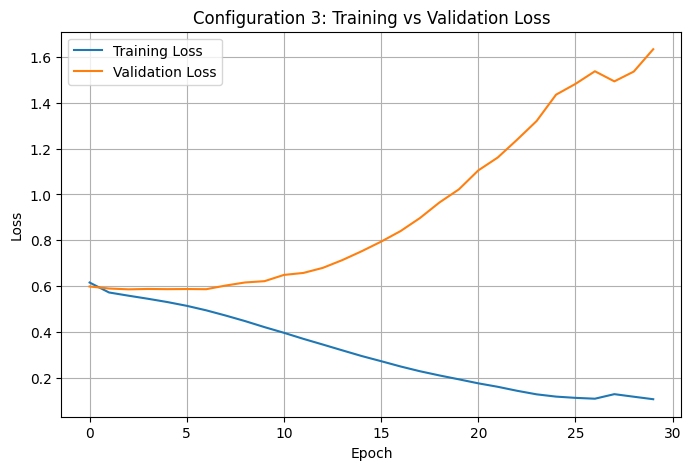

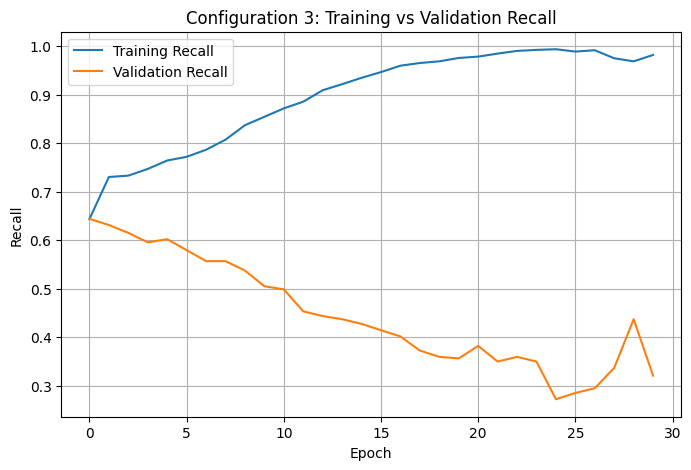

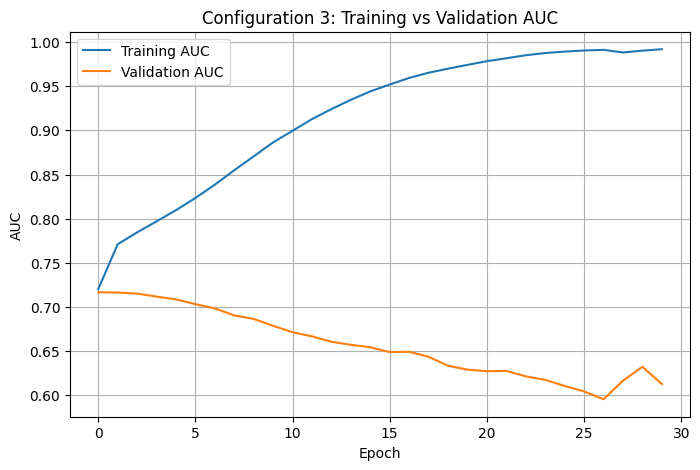

In [ ]:
# Add results to the comparison table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Configuration": "Config 3 - Same DNN (Adam)",
        "Accuracy": config3_accuracy,
        "Precision": config3_precision,
        "Recall": config3_recall,
        "F1_Score": config3_f1,
        "AUC": config3_auc
    }])
], ignore_index=True)


print("RESULTS TABLE AFTER CONFIGURATION 3")
print(results_df)


# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_config3.history['loss'], label='Training Loss')
plt.plot(history_config3.history['val_loss'], label='Validation Loss')
plt.title('Configuration 3: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation recall
plt.figure(figsize=(8, 5))
plt.plot(history_config3.history['recall'], label='Training Recall')
plt.plot(history_config3.history['val_recall'], label='Validation Recall')
plt.title('Configuration 3: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation AUC
plt.figure(figsize=(8, 5))
plt.plot(history_config3.history['auc'], label='Training AUC')
plt.plot(history_config3.history['val_auc'], label='Validation AUC')
plt.title('Configuration 3: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Print last-epoch training history values
print("LAST EPOCH METRICS FOR CONFIGURATION 3")

for key, value in history_config3.history.items():
    print(f"{key}: {value[-1]:.4f}")

LAST EPOCH METRICS FOR CONFIGURATION 3
accuracy: 0.9559
auc: 0.9919
loss: 0.1081
precision: 0.8334
recall: 0.9820
val_accuracy: 0.7253
val_auc: 0.6128
val_loss: 1.6327
val_precision: 0.3289
val_recall: 0.3204


In [ ]:
#  CONFIGURATION 4 - ADAM + DROPOUT + EARLY STOPPING
# Import required libraries
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


# Build Configuration 4 model
# We keep the same general architecture as before, but now
# introduce dropout regularisation between hidden layers.

# Dropout randomly deactivates a proportion of neurons during
# training, helping reduce overfitting.

config4_model = Sequential([
    layers.Input(shape=(input_dim,)),

    # First hidden layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.30),

    # Second hidden layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.30),

    # Third hidden layer
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.20),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
# Adam is retained because it converges efficiently, while
# dropout and early stopping are now introduced to improve
# generalisation.

config4_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)




In [ ]:
# Define early stopping
# Early stopping monitors validation loss and stops training
# when the model stops improving.

# restore_best_weights=True ensures that the best-performing
# model weights are kept at the end.

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# Display model summary
print("CONFIGURATION 4 MODEL SUMMARY")
config4_model.summary()


# Train the model
# The key differences from Config 3 is that dropout  is added and early stopping is added

history_config4 = config4_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

CONFIGURATION 4 MODEL SUMMARY


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 64)             │         6,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5833 - auc: 0.6350 - loss: 0.6639 - precision: 0.2740 - recall: 0.6200 - val_accuracy: 0.6787 - val_auc: 0.7000 - val_loss: 0.6172 - val_precision: 0.3320 - val_recall: 0.5534
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6900 - auc: 0.7280 - loss: 0.6135 - precision: 0.3601 - recall: 0.6498 - val_accuracy: 0.6967 - val_auc: 0.7170 - val_loss: 0.5795 - val_precision: 0.3516 - val_recall: 0.5599
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6966 - auc: 0.7452 - loss: 0.6014 - precision: 0.3710 - recall: 0.6803 - val_accuracy: 0.6840 - val_auc: 0.7193 - val_loss: 0.5838 - val_precision: 0.3469 - val_recall: 0.6052
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6970 - auc: 0.7531 - loss: 0.5929 - precision: 0.3737 - recall: 0.6969 - val_accuracy: 0.6860 - val_auc: 0.7201 - val_loss: 0.5797 - val_precision: 0.3454 - val_recall: 0.5858
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:

# Generate validation predicted probabilities
y_val_pred_prob_config4 = config4_model.predict(X_val_processed).ravel()


# Convert probabilities to predicted classes
y_val_pred_class_config4 = (y_val_pred_prob_config4 >= 0.5).astype(int)


# Compute validation metrics using sklearn
config4_accuracy = accuracy_score(y_val_array, y_val_pred_class_config4)
config4_precision = precision_score(y_val_array, y_val_pred_class_config4, zero_division=0)
config4_recall = recall_score(y_val_array, y_val_pred_class_config4, zero_division=0)
config4_f1 = f1_score(y_val_array, y_val_pred_class_config4, zero_division=0)
config4_auc = roc_auc_score(y_val_array, y_val_pred_prob_config4)


print("CONFIGURATION 4 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config4_accuracy:.4f}")
print(f"Precision: {config4_precision:.4f}")
print(f"Recall   : {config4_recall:.4f}")
print(f"F1-score : {config4_f1:.4f}")
print(f"AUC      : {config4_auc:.4f}")


# Confusion matrix
print("CONFIGURATION 4 - CONFUSION MATRIX (VALIDATION SET)")
cm_config4 = confusion_matrix(y_val_array, y_val_pred_class_config4)
print(cm_config4)


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CONFIGURATION 4 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.7020
Precision: 0.3563
Recall   : 0.5534
F1-score : 0.4335
AUC      : 0.7009
CONFIGURATION 4 - CONFUSION MATRIX (VALIDATION SET)
[[882 309]
 [138 171]]


CONFIGURATION 4 - CLASSIFICATION REPORT (VALIDATION SET)
              precision    recall  f1-score   support

         0.0     0.8647    0.7406    0.7978      1191
         1.0     0.3563    0.5534    0.4335       309

    accuracy                         0.7020      1500
   macro avg     0.6105    0.6470    0.6156      1500
weighted avg     0.7600    0.7020    0.7228      1500

RESULTS TABLE AFTER CONFIGURATION 4
                                       Configuration  Accuracy  Precision    Recall  F1_Score       AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1               Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                         Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...  0.702000   0.356250  0.553398  0.433460  0.700918


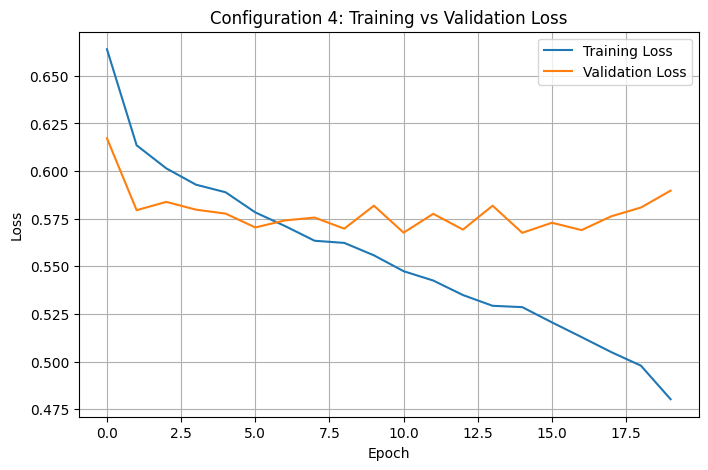

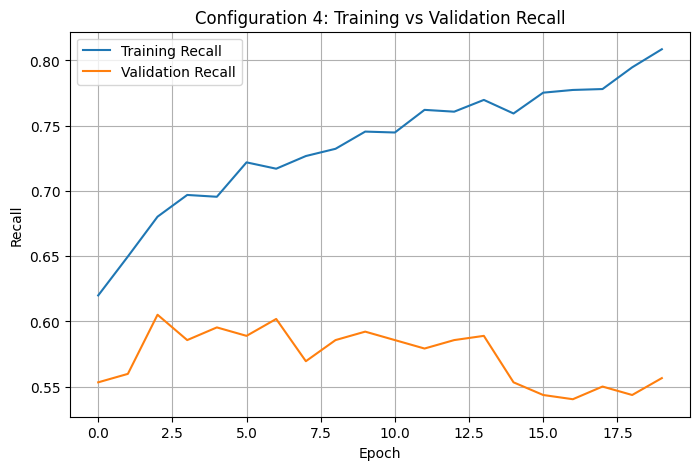

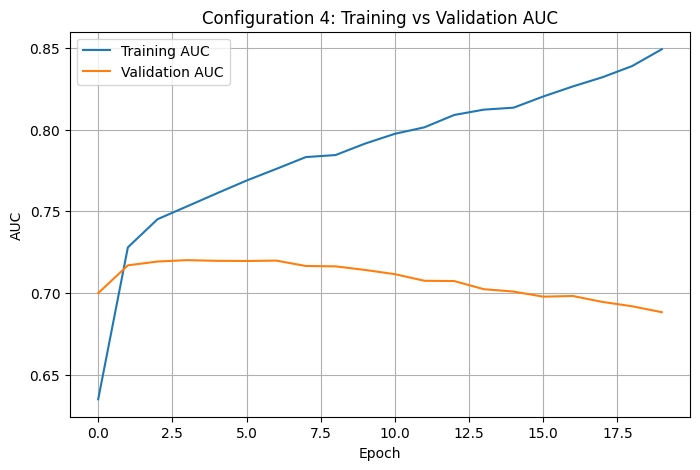

LAST EPOCH METRICS FOR CONFIGURATION 4
accuracy: 0.7499
auc: 0.8492
loss: 0.4803
precision: 0.4415
recall: 0.8086
val_accuracy: 0.6873
val_auc: 0.6883
val_loss: 0.5897
val_precision: 0.3413
val_recall: 0.5566


In [ ]:
# Classification report
print("CONFIGURATION 4 - CLASSIFICATION REPORT (VALIDATION SET)")
print(classification_report(y_val_array, y_val_pred_class_config4, digits=4, zero_division=0))

# Add results to the comparison table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Configuration": "Config 4 - Same DNN (Adam + Dropout + EarlyStopping)",
        "Accuracy": config4_accuracy,
        "Precision": config4_precision,
        "Recall": config4_recall,
        "F1_Score": config4_f1,
        "AUC": config4_auc
    }])
], ignore_index=True)


print("RESULTS TABLE AFTER CONFIGURATION 4")
print(results_df)


# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_config4.history['loss'], label='Training Loss')
plt.plot(history_config4.history['val_loss'], label='Validation Loss')
plt.title('Configuration 4: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation recall
plt.figure(figsize=(8, 5))
plt.plot(history_config4.history['recall'], label='Training Recall')
plt.plot(history_config4.history['val_recall'], label='Validation Recall')
plt.title('Configuration 4: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation AUC
plt.figure(figsize=(8, 5))
plt.plot(history_config4.history['auc'], label='Training AUC')
plt.plot(history_config4.history['val_auc'], label='Validation AUC')
plt.title('Configuration 4: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


# Print last-epoch training history values
print("LAST EPOCH METRICS FOR CONFIGURATION 4")

for key, value in history_config4.history.items():
    print(f"{key}: {value[-1]:.4f}")

In [ ]:
# CONFIGURATION 5 - DEEPER DNN + ADAM + DROPOUT + EARLY STOPPING
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
# Build Configuration 5 model
# This model is deeper than the previous configurations.
# The aim is to test whether additional depth can improve -
# predictive performance when regularisation is already in place.

config5_model = Sequential([
    layers.Input(shape=(input_dim,)),

    # Hidden layer 1
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    # Hidden layer 2
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.30),

    # Hidden layer 3
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.25),

    # Hidden layer 4
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.20),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
config5_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Display model summary
print("CONFIGURATION 5 MODEL SUMMARY")
config5_model.summary()


CONFIGURATION 5 MODEL SUMMARY


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 128)            │        12,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 23,041 (90.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history_config5 = config5_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6536 - auc: 0.6607 - loss: 0.6533 - precision: 0.3073 - recall: 0.5437 - val_accuracy: 0.6820 - val_auc: 0.7194 - val_loss: 0.5758 - val_precision: 0.3473 - val_recall: 0.6181
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6856 - auc: 0.7494 - loss: 0.5972 - precision: 0.3640 - recall: 0.7046 - val_accuracy: 0.6827 - val_auc: 0.7225 - val_loss: 0.5700 - val_precision: 0.3490 - val_recall: 0.6246
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6691 - auc: 0.7588 - loss: 0.5897 - precision: 0.3537 - recall: 0.7323 - val_accuracy: 0.6767 - val_auc: 0.7226 - val_loss: 0.5739 - val_precision: 0.3417 - val_recall: 0.6149
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6873 - auc: 0.7658 - loss: 0.5803 - precision: 0.3692 - recall: 0.7309 - val_accuracy: 0.6853 - val_auc: 0.7230 - val_loss: 0.5638 - val_precision: 0.3499 - val_recall: 0.6149
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:
# Generate validation predicted probabilities
y_val_pred_prob_config5 = config5_model.predict(X_val_processed).ravel()


# Convert probabilities to predicted classes
y_val_pred_class_config5 = (y_val_pred_prob_config5 >= 0.5).astype(int)

# Compute validation metrics using sklearn
config5_accuracy = accuracy_score(y_val_array, y_val_pred_class_config5)
config5_precision = precision_score(y_val_array, y_val_pred_class_config5, zero_division=0)
config5_recall = recall_score(y_val_array, y_val_pred_class_config5, zero_division=0)
config5_f1 = f1_score(y_val_array, y_val_pred_class_config5, zero_division=0)
config5_auc = roc_auc_score(y_val_array, y_val_pred_prob_config5)


print("CONFIGURATION 5 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config5_accuracy:.4f}")
print(f"Precision: {config5_precision:.4f}")
print(f"Recall   : {config5_recall:.4f}")
print(f"F1-score : {config5_f1:.4f}")
print(f"AUC      : {config5_auc:.4f}")


# Confusion matrix
print("CONFIGURATION 5 - CONFUSION MATRIX (VALIDATION SET)")
cm_config5 = confusion_matrix(y_val_array, y_val_pred_class_config5)
print(cm_config5)
print("CONFIGURATION 5 - CLASSIFICATION REPORT (VALIDATION SET)")

print(classification_report(y_val_array, y_val_pred_class_config5, digits=4, zero_division=0))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CONFIGURATION 5 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.6853
Precision: 0.3499
Recall   : 0.6149
F1-score : 0.4460
AUC      : 0.7228
CONFIGURATION 5 - CONFUSION MATRIX (VALIDATION SET)
[[838 353]
 [119 190]]
CONFIGURATION 5 - CLASSIFICATION REPORT (VALIDATION SET)
              precision    recall  f1-score   support

         0.0     0.8757    0.7036    0.7803      1191
         1.0     0.3499    0.6149    0.4460       309

    accuracy                         0.6853      1500
   macro avg     0.6128    0.6592    0.6131      1500
weighted avg     0.7673    0.6853    0.7114      1500



In [ ]:
# Add results to the comparison table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Configuration": "Config 5 - Deeper DNN (Adam + Dropout + EarlyStopping)",
        "Accuracy": config5_accuracy,
        "Precision": config5_precision,
        "Recall": config5_recall,
        "F1_Score": config5_f1,
        "AUC": config5_auc
    }])
], ignore_index=True)


print("RESULTS TABLE AFTER CONFIGURATION 5")
print(results_df)


RESULTS TABLE AFTER CONFIGURATION 5
                                       Configuration  Accuracy  Precision    Recall  F1_Score       AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1               Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                         Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...  0.702000   0.356250  0.553398  0.433460  0.700918
4  Config 5 - Deeper DNN (Adam + Dropout + EarlyS...  0.685333   0.349908  0.614887  0.446009  0.722819


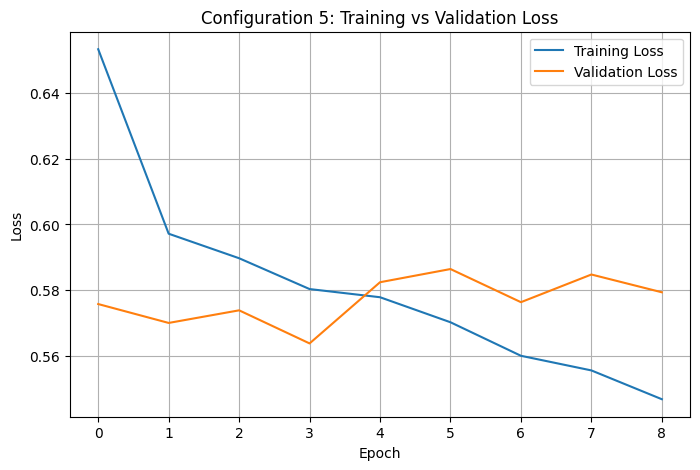

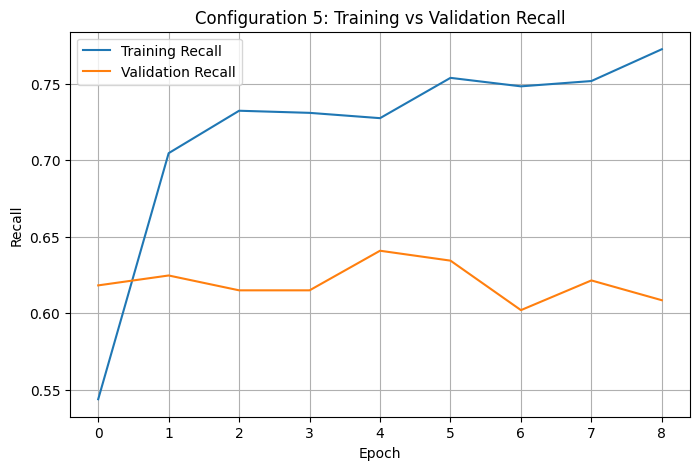

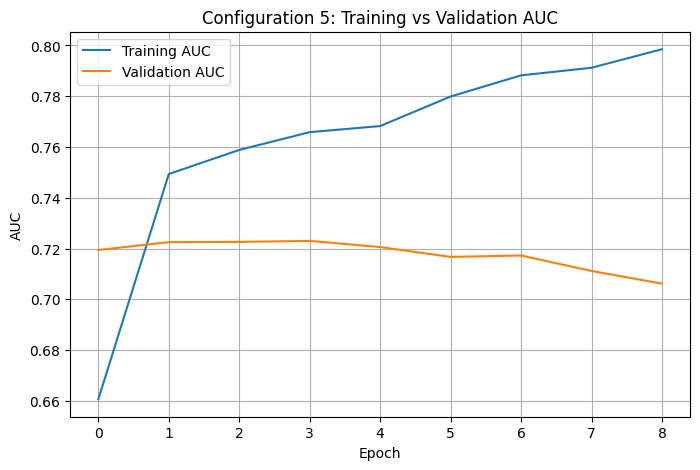

LAST EPOCH METRICS FOR CONFIGURATION 5
accuracy: 0.7039
auc: 0.7985
loss: 0.5468
precision: 0.3896
recall: 0.7725
val_accuracy: 0.6807
val_auc: 0.7062
val_loss: 0.5794
val_precision: 0.3443
val_recall: 0.6084


In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_config5.history['loss'], label='Training Loss')
plt.plot(history_config5.history['val_loss'], label='Validation Loss')
plt.title('Configuration 5: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation recall
plt.figure(figsize=(8, 5))
plt.plot(history_config5.history['recall'], label='Training Recall')
plt.plot(history_config5.history['val_recall'], label='Validation Recall')
plt.title('Configuration 5: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation AUC
plt.figure(figsize=(8, 5))
plt.plot(history_config5.history['auc'], label='Training AUC')
plt.plot(history_config5.history['val_auc'], label='Validation AUC')
plt.title('Configuration 5: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


# Print last-epoch training history values
print("LAST EPOCH METRICS FOR CONFIGURATION 5")

for key, value in history_config5.history.items():
    print(f"{key}: {value[-1]:.4f}")

In [ ]:
# Import required libraries

import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
 # Build Configuration 6 model
# This configuration is an extension of Config 5 by adding L2 regularisation.

l2_strength = 0.001

config6_model = Sequential([
    layers.Input(shape=(input_dim,)),

    # Hidden layer 1
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.30),

    # Hidden layer 2
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.30),

    # Hidden layer 3
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.25),

    # Hidden layer 4
    layers.Dense(16, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.20),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
config6_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Display model summary
print("CONFIGURATION 6 MODEL SUMMARY")
config6_model.summary()


CONFIGURATION 6 MODEL SUMMARY


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 128)            │        12,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 23,041 (90.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history_config6 = config6_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5976 - auc: 0.6625 - loss: 0.8613 - precision: 0.2885 - recall: 0.6505 - val_accuracy: 0.6800 - val_auc: 0.7233 - val_loss: 0.7533 - val_precision: 0.3481 - val_recall: 0.6343
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6633 - auc: 0.7432 - loss: 0.7606 - precision: 0.3476 - recall: 0.7233 - val_accuracy: 0.6707 - val_auc: 0.7261 - val_loss: 0.7269 - val_precision: 0.3430 - val_recall: 0.6537
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6833 - auc: 0.7558 - loss: 0.7155 - precision: 0.3646 - recall: 0.7233 - val_accuracy: 0.6727 - val_auc: 0.7255 - val_loss: 0.6813 - val_precision: 0.3415 - val_recall: 0.6343
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6883 - auc: 0.7600 - loss: 0.6861 - precision: 0.3718 - recall: 0.7441 - val_accuracy: 0.6627 - val_auc: 0.7246 - val_loss: 0.6780 - val_precision: 0.3339 - val_recall: 0.6408
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:
# Generate validation predicted probabilities
y_val_pred_prob_config6 = config6_model.predict(X_val_processed).ravel()

# Convert probabilities to predicted classes
y_val_pred_class_config6 = (y_val_pred_prob_config6 >= 0.5).astype(int)

# Compute validation metrics using sklearn
config6_accuracy = accuracy_score(y_val_array, y_val_pred_class_config6)
config6_precision = precision_score(y_val_array, y_val_pred_class_config6, zero_division=0)
config6_recall = recall_score(y_val_array, y_val_pred_class_config6, zero_division=0)
config6_f1 = f1_score(y_val_array, y_val_pred_class_config6, zero_division=0)
config6_auc = roc_auc_score(y_val_array, y_val_pred_prob_config6)

print("CONFIGURATION 6 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config6_accuracy:.4f}")
print(f"Precision: {config6_precision:.4f}")
print(f"Recall   : {config6_recall:.4f}")
print(f"F1-score : {config6_f1:.4f}")
print(f"AUC      : {config6_auc:.4f}")


# Confusion matrix
print("CONFIGURATION 6 - CONFUSION MATRIX (VALIDATION SET)")
cm_config6 = confusion_matrix(y_val_array, y_val_pred_class_config6)
print(cm_config6)

# Classification report
print("CONFIGURATION 6 - CLASSIFICATION REPORT (VALIDATION SET)")
print(classification_report(y_val_array, y_val_pred_class_config6, digits=4, zero_division=0))


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CONFIGURATION 6 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.6833
Precision: 0.3480
Recall   : 0.6149
F1-score : 0.4444
AUC      : 0.7198
CONFIGURATION 6 - CONFUSION MATRIX (VALIDATION SET)
[[835 356]
 [119 190]]
CONFIGURATION 6 - CLASSIFICATION REPORT (VALIDATION SET)
              precision    recall  f1-score   support

         0.0     0.8753    0.7011    0.7786      1191
         1.0     0.3480    0.6149    0.4444       309

    accuracy                         0.6833      1500
   macro avg     0.6116    0.6580    0.6115      1500
weighted avg     0.7666    0.6833    0.7097      1500



RESULTS TABLE AFTER CONFIGURATION 6
                                       Configuration  Accuracy  Precision    Recall  F1_Score       AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1               Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                         Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...  0.702000   0.356250  0.553398  0.433460  0.700918
4  Config 5 - Deeper DNN (Adam + Dropout + EarlyS...  0.685333   0.349908  0.614887  0.446009  0.722819
5  Config 6 - Deeper DNN (Adam + Dropout + L2 + E...  0.683333   0.347985  0.614887  0.444444  0.719827


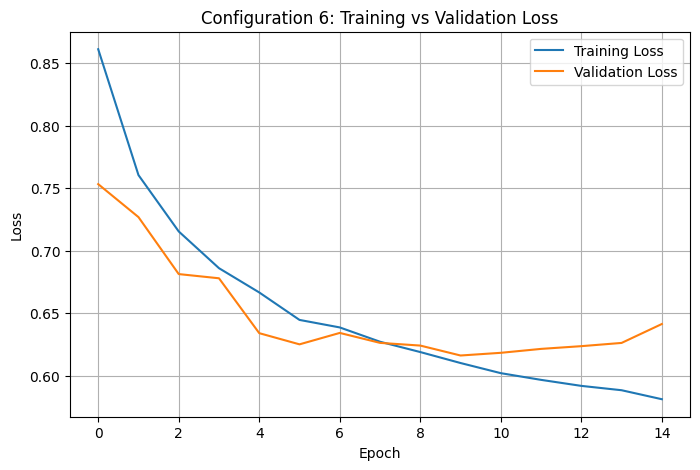

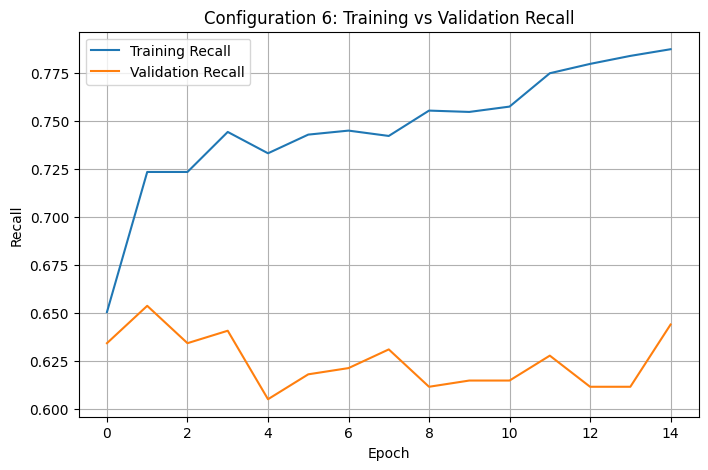

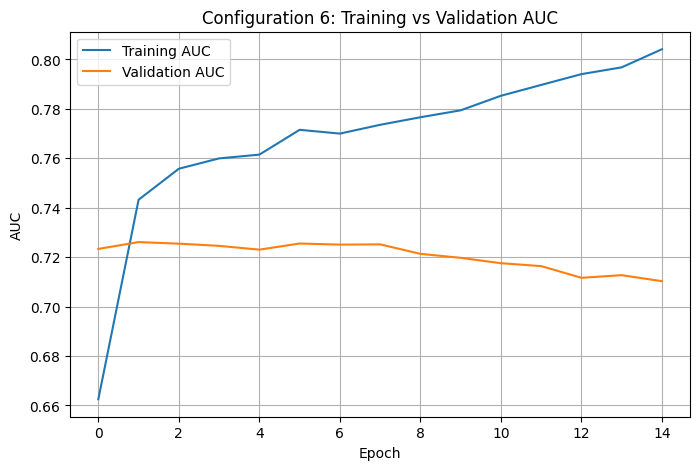

In [ ]:
# Add results to the comparison table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Configuration": "Config 6 - Deeper DNN (Adam + Dropout + L2 + EarlyStopping)",
        "Accuracy": config6_accuracy,
        "Precision": config6_precision,
        "Recall": config6_recall,
        "F1_Score": config6_f1,
        "AUC": config6_auc
    }])
], ignore_index=True)

# cleanup in case of accidental duplicate rows
results_df = results_df.drop_duplicates().reset_index(drop=True)


print("RESULTS TABLE AFTER CONFIGURATION 6")
print(results_df)

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_config6.history['loss'], label='Training Loss')
plt.plot(history_config6.history['val_loss'], label='Validation Loss')
plt.title('Configuration 6: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation recall
plt.figure(figsize=(8, 5))
plt.plot(history_config6.history['recall'], label='Training Recall')
plt.plot(history_config6.history['val_recall'], label='Validation Recall')
plt.title('Configuration 6: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()


# Plot training and validation AUC
plt.figure(figsize=(8, 5))
plt.plot(history_config6.history['auc'], label='Training AUC')
plt.plot(history_config6.history['val_auc'], label='Validation AUC')
plt.title('Configuration 6: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("LAST EPOCH METRICS FOR CONFIGURATION 6")

for key, value in history_config6.history.items():
    print(f"{key}: {value[-1]:.4f}")

LAST EPOCH METRICS FOR CONFIGURATION 6
accuracy: 0.7124
auc: 0.8041
loss: 0.5812
precision: 0.3995
recall: 0.7871
val_accuracy: 0.6593
val_auc: 0.7103
val_loss: 0.6414
val_precision: 0.3317
val_recall: 0.6440


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Build Configuration 7 model
# This is the same architecture as Config 6.
# The only main change is a smaller learning rate.
# To tests whether gentler optimisation improves generalisation.

l2_strength = 0.001

config7_model = Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.30),

    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.30),

    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.25),

    layers.Dense(16, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dropout(0.20),

    layers.Dense(1, activation='sigmoid')
])

# Compile the model-
# Only the learning rate is changed here:
# Adam(0.0005) instead of Adam(0.001)

config7_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


In [ ]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
# Display model summary
print("CONFIGURATION 7 MODEL SUMMARY")
config7_model.summary()

# Train the model
history_config7 = config7_model.fit(
    X_train_processed,
    y_train_array,
    validation_data=(X_val_processed, y_val_array),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)


# Generate validation predicted probabilities
y_val_pred_prob_config7 = config7_model.predict(X_val_processed).ravel()


CONFIGURATION 7 MODEL SUMMARY


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 128)            │        12,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 23,041 (90.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6297 - auc: 0.6296 - loss: 0.9052 - precision: 0.2830 - recall: 0.5201 - val_accuracy: 0.6533 - val_auc: 0.7187 - val_loss: 0.8393 - val_precision: 0.3333 - val_recall: 0.6828
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6596 - auc: 0.7205 - loss: 0.8331 - precision: 0.3383 - recall: 0.6824 - val_accuracy: 0.6820 - val_auc: 0.7231 - val_loss: 0.7921 - val_precision: 0.3495 - val_recall: 0.6311
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6764 - auc: 0.7381 - loss: 0.7985 - precision: 0.3536 - recall: 0.6893 - val_accuracy: 0.6773 - val_auc: 0.7271 - val_loss: 0.7715 - val_precision: 0.3489 - val_recall: 0.6537
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6864 - auc: 0.7488 - loss: 0.7694 - precision: 0.3642 - recall: 0.7004 - val_accuracy: 0.6847 - val_auc: 0.7280 - val_loss: 0.7533 - val_precision: 0.3520 - val_recall: 0.6311
Epoch 5/30
219/219 ━━━━━━━━━━━━━

In [ ]:
# Convert probabilities to predicted classes
y_val_pred_class_config7 = (y_val_pred_prob_config7 >= 0.5).astype(int)


# Compute validation metrics using sklearn
config7_accuracy = accuracy_score(y_val_array, y_val_pred_class_config7)
config7_precision = precision_score(y_val_array, y_val_pred_class_config7, zero_division=0)
config7_recall = recall_score(y_val_array, y_val_pred_class_config7, zero_division=0)
config7_f1 = f1_score(y_val_array, y_val_pred_class_config7, zero_division=0)
config7_auc = roc_auc_score(y_val_array, y_val_pred_prob_config7)

print("CONFIGURATION 7 - VALIDATION METRICS (SKLEARN)")
print(f"Accuracy : {config7_accuracy:.4f}")
print(f"Precision: {config7_precision:.4f}")
print(f"Recall   : {config7_recall:.4f}")
print(f"F1-score : {config7_f1:.4f}")
print(f"AUC      : {config7_auc:.4f}")

CONFIGURATION 7 - VALIDATION METRICS (SKLEARN)
Accuracy : 0.6927
Precision: 0.3538
Recall   : 0.5955
F1-score : 0.4439
AUC      : 0.7084


In [ ]:
# Confusion matrix
print("CONFIGURATION 7 - CONFUSION MATRIX (VALIDATION SET)")
cm_config7 = confusion_matrix(y_val_array, y_val_pred_class_config7)
print(cm_config7)

# Classification report
print("CONFIGURATION 7 - CLASSIFICATION REPORT (VALIDATION SET)")
print(classification_report(y_val_array, y_val_pred_class_config7, digits=4, zero_division=0))


CONFIGURATION 7 - CONFUSION MATRIX (VALIDATION SET)
[[855 336]
 [125 184]]
CONFIGURATION 7 - CLASSIFICATION REPORT (VALIDATION SET)
              precision    recall  f1-score   support

         0.0     0.8724    0.7179    0.7877      1191
         1.0     0.3538    0.5955    0.4439       309

    accuracy                         0.6927      1500
   macro avg     0.6131    0.6567    0.6158      1500
weighted avg     0.7656    0.6927    0.7168      1500



In [ ]:
# Add results to the comparison table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Configuration": "Config 7 - Deeper DNN (Adam 0.0005 + Dropout + L2 + EarlyStopping)",
        "Accuracy": config7_accuracy,
        "Precision": config7_precision,
        "Recall": config7_recall,
        "F1_Score": config7_f1,
        "AUC": config7_auc
    }])
], ignore_index=True)

results_df = results_df.drop_duplicates().reset_index(drop=True)

print("RESULTS TABLE AFTER CONFIGURATION 7")
print(results_df)


RESULTS TABLE AFTER CONFIGURATION 7
                                       Configuration  Accuracy  Precision    Recall  F1_Score       AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1               Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                         Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...  0.702000   0.356250  0.553398  0.433460  0.700918
4  Config 5 - Deeper DNN (Adam + Dropout + EarlyS...  0.685333   0.349908  0.614887  0.446009  0.722819
5  Config 6 - Deeper DNN (Adam + Dropout + L2 + E...  0.683333   0.347985  0.614887  0.444444  0.719827
6  Config 7 - Deeper DNN (Adam 0.0005 + Dropout +...  0.692667   0.353846  0.595469  0.443908  0.708401


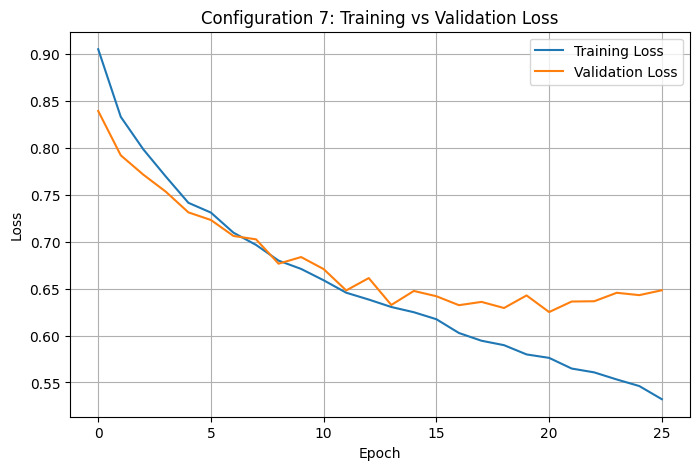

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_config7.history['loss'], label='Training Loss')
plt.plot(history_config7.history['val_loss'], label='Validation Loss')
plt.title('Configuration 7: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

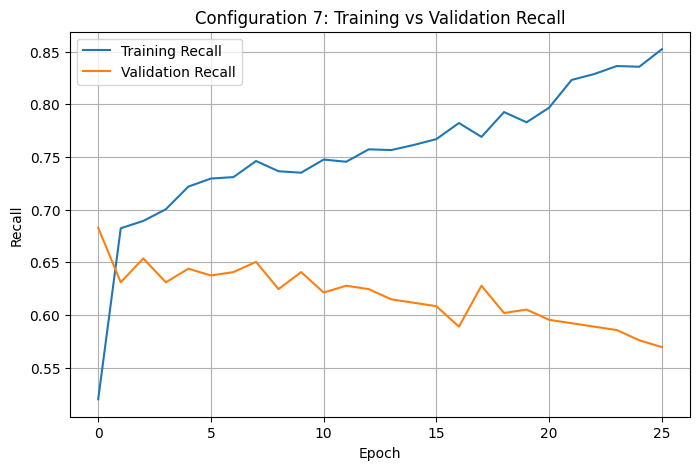

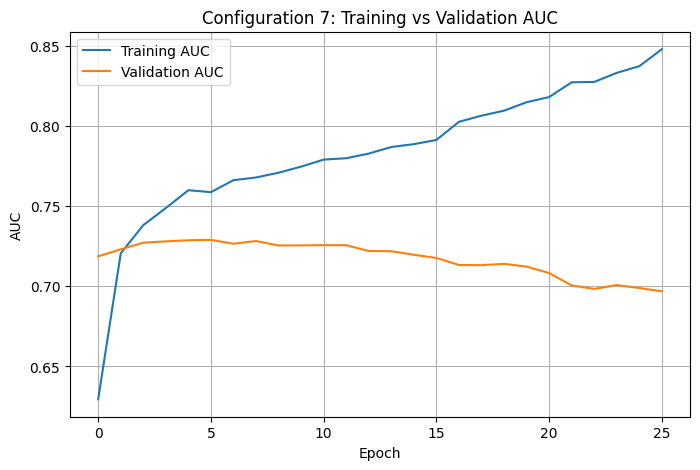

In [ ]:
# Plot training and validation recall
plt.figure(figsize=(8, 5))
plt.plot(history_config7.history['recall'], label='Training Recall')
plt.plot(history_config7.history['val_recall'], label='Validation Recall')
plt.title('Configuration 7: Training vs Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

# 16. Plot training and validation AUC
plt.figure(figsize=(8, 5))
plt.plot(history_config7.history['auc'], label='Training AUC')
plt.plot(history_config7.history['val_auc'], label='Validation AUC')
plt.title('Configuration 7: Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Print last-epoch training history values
print("LAST EPOCH METRICS FOR CONFIGURATION 7")

for key, value in history_config7.history.items():
    print(f"{key}: {value[-1]:.4f}")

LAST EPOCH METRICS FOR CONFIGURATION 7
accuracy: 0.7374
auc: 0.8478
loss: 0.5321
precision: 0.4306
recall: 0.8523
val_accuracy: 0.6907
val_auc: 0.6969
val_loss: 0.6482
val_precision: 0.3471
val_recall: 0.5696


In [ ]:
# Make a copy so I don’t overwrite original
comparison_df = results_df.copy()

# Round values for cleaner presentation
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC']]


# Optional: Rename columns for nicer display
comparison_df = comparison_df.rename(columns={
    'F1_Score': 'F1-score'
})

print("MODEL COMPARISON TABLE")
print(comparison_df)

MODEL COMPARISON TABLE
                                       Configuration  Accuracy  Precision    Recall  F1-score       AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1               Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                         Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...  0.702000   0.356250  0.553398  0.433460  0.700918
4  Config 5 - Deeper DNN (Adam + Dropout + EarlyS...  0.685333   0.349908  0.614887  0.446009  0.722819
5  Config 6 - Deeper DNN (Adam + Dropout + L2 + E...  0.683333   0.347985  0.614887  0.444444  0.719827
6  Config 7 - Deeper DNN (Adam 0.0005 + Dropout +...  0.692667   0.353846  0.595469  0.443908  0.708401


In [ ]:
# I'd like to show columns without wrapping
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(comparison_df)

                                       Configuration  Accuracy  Precision    Recall  F1-score       AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)  0.682000   0.342697  0.592233  0.434164  0.719370
1               Config 2 - Same DNN (SGD + momentum)  0.686667   0.321508  0.469256  0.381579  0.649056
2                         Config 3 - Same DNN (Adam)  0.725333   0.328904  0.320388  0.324590  0.632389
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...  0.702000   0.356250  0.553398  0.433460  0.700918
4  Config 5 - Deeper DNN (Adam + Dropout + EarlyS...  0.685333   0.349908  0.614887  0.446009  0.722819
5  Config 6 - Deeper DNN (Adam + Dropout + L2 + E...  0.683333   0.347985  0.614887  0.444444  0.719827
6  Config 7 - Deeper DNN (Adam 0.0005 + Dropout +...  0.692667   0.353846  0.595469  0.443908  0.708401


In [ ]:
# FINAL TEST EVALUATION FOR ALL MODEL CONFIGURATIONS
# Storing all final trained models in a dictionary

models_dict = {
    "Config 1 - Baseline DNN (SGD, no regularisation)": config1_model,
    "Config 2 - Same DNN (SGD + momentum)": config2_model,
    "Config 3 - Same DNN (Adam)": config3_model,
    "Config 4 - Same DNN (Adam + Dropout + EarlyStopping)": config4_model,
    "Config 5 - Deeper DNN (Adam + Dropout + EarlyStopping)": config5_model,
    "Config 6 - Deeper DNN (Adam + Dropout + L2 + EarlyStopping)": config6_model,
    "Config 7 - Deeper DNN (Adam 0.0005 + Dropout + L2 + EarlyStopping)": config7_model
}


# Creating empty list to store test results

test_results = []



In [ ]:
# Loop through each model and evaluate on the test set
for model_name, model in models_dict.items():

    # Predict probabilities on the test set
    y_test_pred_prob = model.predict(X_test_processed).ravel()

    # Convert probabilities to class predictions using threshold = 0.5
    y_test_pred_class = (y_test_pred_prob >= 0.5).astype(int)

    # Compute evaluation metrics
    test_accuracy = accuracy_score(y_test_array, y_test_pred_class)
    test_precision = precision_score(y_test_array, y_test_pred_class, zero_division=0)
    test_recall = recall_score(y_test_array, y_test_pred_class, zero_division=0)
    test_f1 = f1_score(y_test_array, y_test_pred_class, zero_division=0)
    test_auc = roc_auc_score(y_test_array, y_test_pred_prob)

    # Store results
    test_results.append({
        "Configuration": model_name,
        "Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall,
        "F1-score": test_f1,
        "AUC": test_auc
    })


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# Converting results into a DataFrame
test_results_df = pd.DataFrame(test_results)


# Rounding values for cleaner presentation
test_results_df[["Accuracy", "Precision", "Recall", "F1-score", "AUC"]] = (
    test_results_df[["Accuracy", "Precision", "Recall", "F1-score", "AUC"]].round(3)
)

#  Display the full test comparison table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("TEST SET COMPARISON TABLE FOR ALL CONFIGURATIONS")
print(test_results_df)

TEST SET COMPARISON TABLE FOR ALL CONFIGURATIONS
                                       Configuration  Accuracy  Precision  Recall  F1-score    AUC
0   Config 1 - Baseline DNN (SGD, no regularisation)     0.697      0.364   0.634     0.463  0.722
1               Config 2 - Same DNN (SGD + momentum)     0.681      0.318   0.482     0.384  0.662
2                         Config 3 - Same DNN (Adam)     0.716      0.324   0.350     0.336  0.645
3  Config 4 - Same DNN (Adam + Dropout + EarlySto...     0.704      0.365   0.592     0.452  0.716
4  Config 5 - Deeper DNN (Adam + Dropout + EarlyS...     0.703      0.372   0.641     0.471  0.740
5  Config 6 - Deeper DNN (Adam + Dropout + L2 + E...     0.687      0.351   0.608     0.445  0.731
6  Config 7 - Deeper DNN (Adam 0.0005 + Dropout +...     0.693      0.354   0.599     0.445  0.711


In [ ]:
#  identifying the best model by Recall, F1, and AUC

best_recall_row = test_results_df.loc[test_results_df["Recall"].idxmax()]
best_f1_row = test_results_df.loc[test_results_df["F1-score"].idxmax()]
best_auc_row = test_results_df.loc[test_results_df["AUC"].idxmax()]


print("BEST MODEL BY RECALL")
print(best_recall_row)

print("BEST MODEL BY F1-SCORE")
print(best_f1_row)


print("BEST MODEL BY AUC")
print(best_auc_row)

BEST MODEL BY RECALL
Configuration    Config 5 - Deeper DNN (Adam + Dropout + EarlyS...
Accuracy                                                     0.703
Precision                                                    0.372
Recall                                                       0.641
F1-score                                                     0.471
AUC                                                           0.74
Name: 4, dtype: object
BEST MODEL BY F1-SCORE
Configuration    Config 5 - Deeper DNN (Adam + Dropout + EarlyS...
Accuracy                                                     0.703
Precision                                                    0.372
Recall                                                       0.641
F1-score                                                     0.471
AUC                                                           0.74
Name: 4, dtype: object
BEST MODEL BY AUC
Configuration    Config 5 - Deeper DNN (Adam + Dropout + EarlyS...
Accuracy             

In [ ]:

# DETAILED TEST REPORT FOR EACH CONFIGURATION

for model_name, model in models_dict.items():
    print(f"TEST SET DETAILED RESULTS: {model_name}")


    # Predict probabilities and classes
    y_test_pred_prob = model.predict(X_test_processed).ravel()
    y_test_pred_class = (y_test_pred_prob >= 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test_array, y_test_pred_class)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test_array, y_test_pred_class, digits=4, zero_division=0))

TEST SET DETAILED RESULTS: Config 1 - Baseline DNN (SGD, no regularisation)
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Confusion Matrix:
[[849 342]
 [113 196]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.8825    0.7128    0.7887      1191
         1.0     0.3643    0.6343    0.4628       309

    accuracy                         0.6967      1500
   macro avg     0.6234    0.6736    0.6257      1500
weighted avg     0.7758    0.6967    0.7215      1500

TEST SET DETAILED RESULTS: Config 2 - Same DNN (SGD + momentum)
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
[[872 319]
 [160 149]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.8450    0.7322    0.7845      1191
         1.0     0.3184    0.4822    0.3835       309

    accuracy                         0.6807      1500
   macro avg     0.5817    0.6072    0.5840      1500
weighted avg     0.7365    0.6807    0.7019      15

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


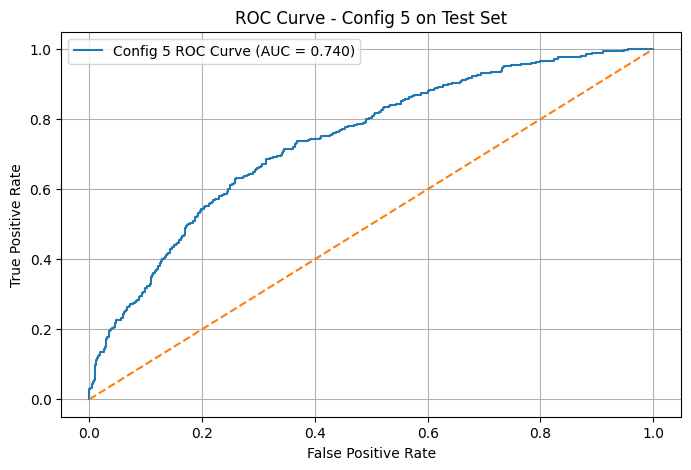

In [ ]:
# ROC CURVE - CONFIG 5 ON TEST SET

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for Config 5 on the test set
y_test_pred_prob_config5 = config5_model.predict(X_test_processed).ravel()

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test_array, y_test_pred_prob_config5)
auc_config5_test = roc_auc_score(y_test_array, y_test_pred_prob_config5)

# Plot ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'Config 5 ROC Curve (AUC = {auc_config5_test:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve - Config 5 on Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

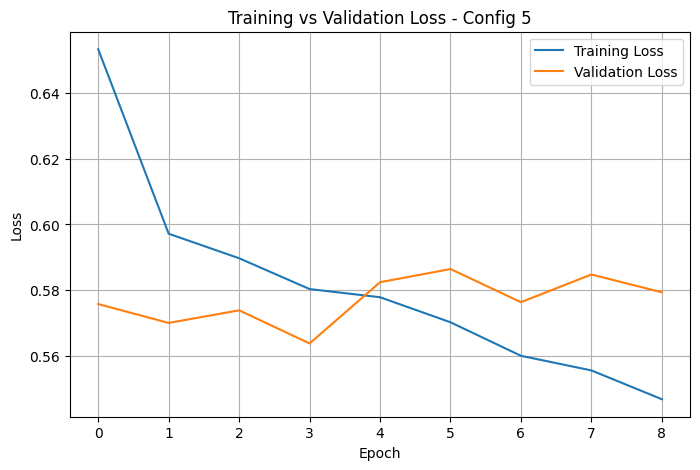

In [ ]:
# TRAINING VS VALIDATION LOSS - CONFIG 5
plt.figure(figsize=(8, 5))
plt.plot(history_config5.history['loss'], label='Training Loss')
plt.plot(history_config5.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss - Config 5')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

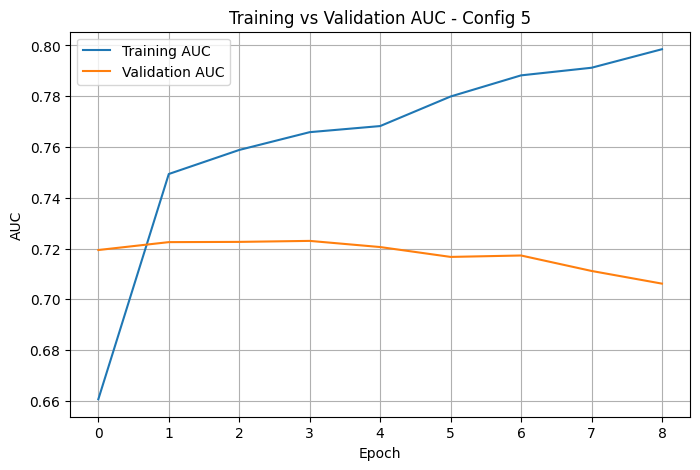

In [ ]:
# TRAINING VS VALIDATION AUC - CONFIG 5
plt.figure(figsize=(8, 5))
plt.plot(history_config5.history['auc'], label='Training AUC')
plt.plot(history_config5.history['val_auc'], label='Validation AUC')
plt.title('Training vs Validation AUC - Config 5')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()